In [1]:
import numpy as np
import matplotlib.pyplot as plt

### (1) ZEUS NC DIS data

In [2]:
# Number of Q2 bins in ZEUS data
Nz = 18

# Tables of ZEUS 1994-2007 data 

# Measured events in Q2 bins:

data = np.array([35518, 33620, 29715, 23507, 18450, 14188, 10872,  8085,  6244,
                 4593,  6083,  3218,  1671,   727,   339,   150,    42,     9],dtype=np.int32)

# Expected events in Q2 bins:

nexp = np.array([36408.886, 33962.516, 30180.386, 23916.275, 18620.044, 14374.440, 
                10998.995,  8377.201,  6278.281,  4738.714,  6142.409,  3326.675,  
                 1678.169,   780.170,   337.196,   139.448,    44.217,     8.795])

# effective Q2 values for each

Q2 = np.array([616.884,   733.594,   872.376,  1037.266,  1233.367,  1466.970,  
              1744.936,  2075.208,  2467.738,  2934.485,  3805.260,  5381.450,
              7610.939, 10763.494, 15221.038, 21525.798, 30442.076, 43051.597])

print(f'Total of {np.sum(data)} events observed, {np.sum(nexp)} expected')

Total of 197031 events observed, 200312.817 expected


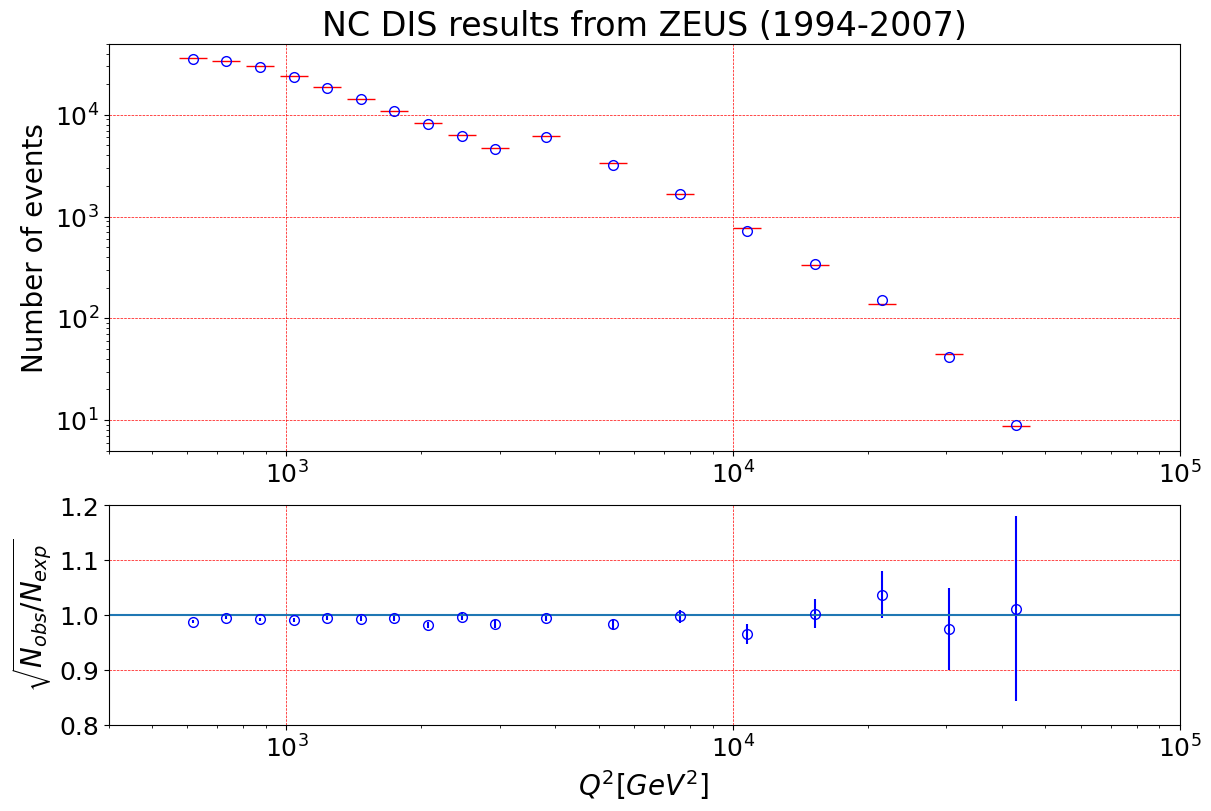

In [3]:
    
plt.subplots(2,1,figsize=(12, 8),height_ratios=(0.65,0.35),layout='constrained')

plt.subplot(211)

plt.plot(Q2,nexp,'r_',ms=20.)
plt.plot(Q2,data,'bo',ms=7.,fillstyle='none')

plt.title("NC DIS results from ZEUS (1994-2007)",size=24)
plt.ylabel('Number of events',size=20)

plt.xscale("log")
plt.yscale("log")

plt.xlim([400.,100000.])
plt.ylim([5.,50000.])
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)


plt.subplot(212)

plt.errorbar(Q2,np.sqrt(data/nexp),1./np.sqrt(4.*nexp),marker='o',color='blue',markersize=7.,linestyle='',fillstyle='none')

plt.ylabel('$\\sqrt{N_{obs}/N_{exp}}$',size=20)
plt.xlabel('$Q^{2}   [GeV^2]$ ',size=20)

plt.xscale("log")
plt.xlim([400.,100000.])
plt.ylim([0.8,1.2])
plt.hlines(1.,400.,100000.)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)

fname = '06_zeus_rq_data.png'
plt.savefig(fname)

### (2) Expected deviations from finite quark radius

In [4]:
# Unit conversion factor

GeVfm = 0.197326980   # [GeV * fm]

# Function to extract "best" Rq value from the data

def rq2fit(Q2,data,nexp):

    RS = np.sqrt(data/nexp)
    
    errinv = np.sqrt(4.*nexp)

    pars = np.polyfit(Q2, np.transpose(RS), 1,  w=errinv)

    return -6.*pars[0] * GeVfm*GeVfm, pars[1]      # Change Rq^2 units from GeV^-2 to fm^2 

Rq2data,Rdata = rq2fit(Q2,data,nexp)

print(f'Fit to ZEUS data gives Rq^2 = {Rq2data:.3g} fm^2')
print(f'Normalization offset  R = {Rdata-1:.5f}')

Fit to ZEUS data gives Rq^2 = 2.75e-08 fm^2
Normalization offset  R = -0.00807


In [5]:
# Generate pseudo-data
# Assume quark radius of 10^{-18} m = 0.001 fm

Rq = 0.001  # [fm]

expRq = Rdata * nexp * (1 - Q2*Rq*Rq/GeVfm/GeVfm/6.)**2    # Rq model expectations 

Rqdata = np.random.poisson(expRq)

Rq2fit,Rfit = rq2fit(Q2,Rqdata,nexp)

print(f'Fit to pseudo-data gives Rq^2 = {Rq2fit:.3g} fm^2')

Fit to pseudo-data gives Rq^2 = 9.67e-07 fm^2


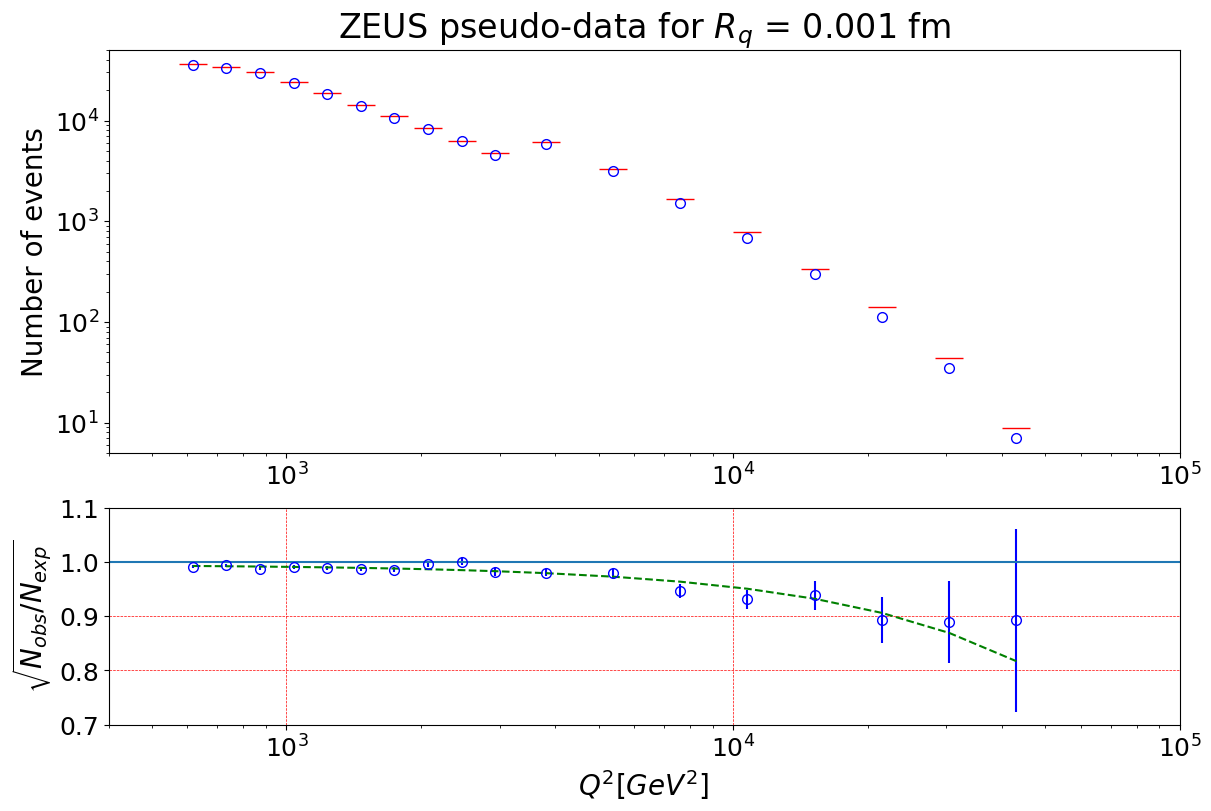

In [6]:
    
plt.subplots(2,1,figsize=(12, 8),height_ratios=(0.65,0.35),layout='constrained')

plt.subplot(211)

plt.plot(Q2,nexp,'r_',ms=20.)
plt.plot(Q2,Rqdata,'bo',ms=7.,fillstyle='none')

plt.title(f"ZEUS pseudo-data for $R_q$ = {Rq} fm",size=24)
plt.ylabel('Number of events',size=20)

plt.xscale("log")
plt.yscale("log")

plt.xlim([400.,100000.])
plt.ylim([5.,50000.])
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)


plt.subplot(212)

plt.errorbar(Q2,np.sqrt(Rqdata/nexp),1./np.sqrt(4.*nexp),marker='o',color='blue',markersize=7.,linestyle='',fillstyle='none')

fval = (Rfit - Q2*Rq2fit/GeVfm/GeVfm/6.)
plt.plot(Q2,fval,'g--')

plt.ylabel('$\\sqrt{N_{obs}/N_{exp}}$',size=20)
plt.xlabel('$Q^{2}   [GeV^2]$ ',size=20)

plt.xscale("log")
plt.xlim([400.,100000.])
plt.ylim([0.7,1.1])
plt.hlines(1.,400.,100000.)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)

fname = '06_zeus_rq_check.png'
plt.savefig(fname)

### (3) Generate MC experiments 

To compare $R_q$ model expectations with the result of the fit to the actual data

In [7]:
# Generate multiple MC experiments for given Rq and extract Rq^2 from the fit

def mcexp(Rmc,Nmc):

    expmc = nexp * (1 - Q2*Rmc*Rmc/GeVfm/GeVfm/6.)**2

    MCdata = np.random.poisson(expmc,size=(Nmc,Nz))

    RS = np.sqrt(MCdata/expmc)

    Rq2mc,_ = rq2fit(Q2,MCdata,nexp)

    return Rq2mc



In [8]:
# Run MC experiments for SM and BSM hypothesis

Nmc=10000

Rsm = 0.
Rq = 0.001

Rq2sm = mcexp(Rsm,Nmc)
Rq2mc = mcexp(Rq,Nmc)

frac = np.sum(Rq2mc>Rq2data)/Nmc

print(f'Model with quark radius of {Rq} fm  gives higher Rq value with probability of {frac:.8f}')

Model with quark radius of 0.001 fm  gives higher Rq value with probability of 1.00000000


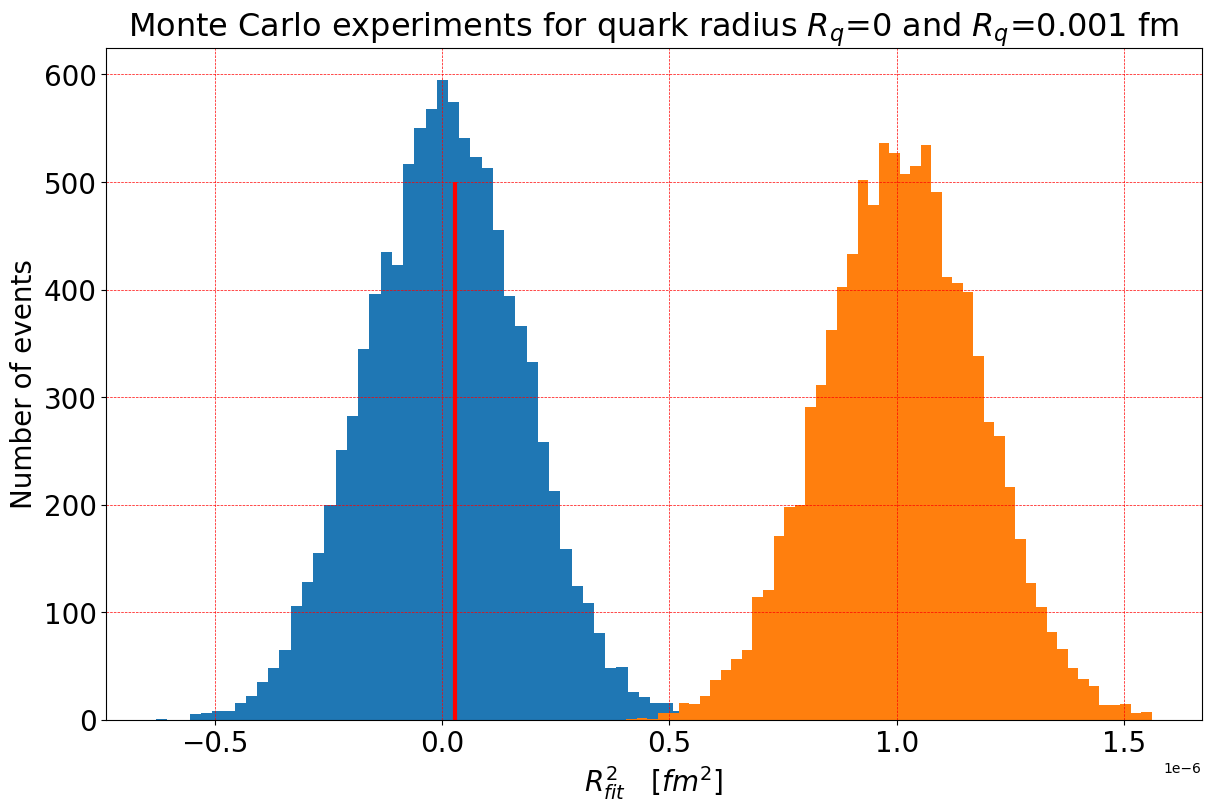

In [9]:
plt.figure(figsize=(12, 8),layout='constrained')

plt.hist(Rq2sm,bins=50,label='$R_q = 0$')
plt.hist(Rq2mc,bins=50,label=f'$R_q = {Rq} fm')

plt.vlines(Rq2data,0.,Nmc/20.,linewidth=3,color='red')

plt.title(f"Monte Carlo experiments for quark radius $R_q$=0 and $R_q$={Rq} fm",size=23)
plt.ylabel('Number of events',size=20)
plt.xlabel('$R_{fit}^2$   $[fm^2]$',size=20)

#plt.xscale("log")
# plt.yscale("log")

# plt.xlim([400.,100000.])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)

fname = '06_zeus_rq_hist.png'
plt.savefig(fname)

### (4) Procedure for frequentist limit determination

In [10]:
# Scan for limit

Ntab = 101

Rtab = np.linspace(0.,0.001,Ntab)

ftab = np.empty(Ntab)

for itab in range(Ntab):

    Rq2mc = mcexp(Rtab[itab],Nmc)

    ftab[itab] = np.sum(Rq2mc>Rq2data)/Nmc


CL=0.95
ilim = np.argmax(ftab>CL)    # for 95% CL limit
Rqlim = Rtab[ilim]

print(f'Extracted {100*CL:.0f}% CL limit  Rq < {Rqlim:.5f} fm')

Extracted 95% CL limit  Rq < 0.00055 fm


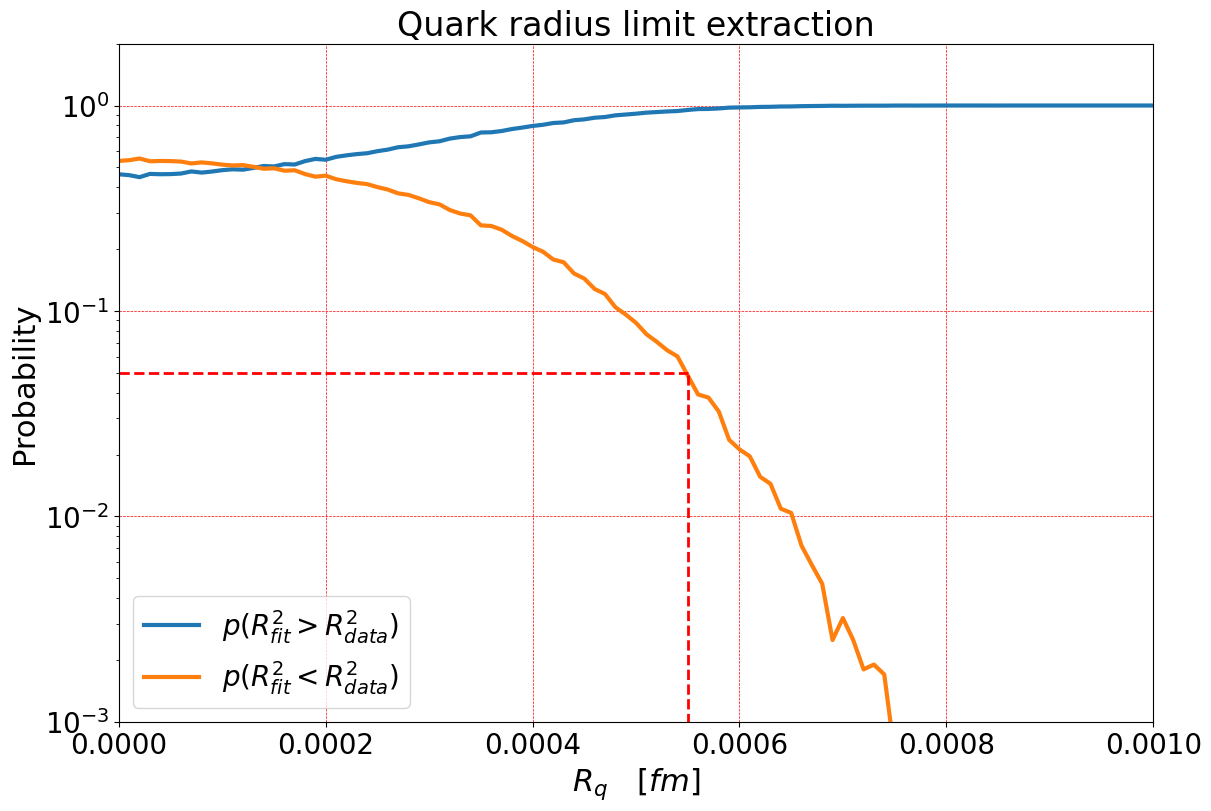

In [11]:
plt.figure(figsize=(12, 8),layout='constrained')

plt.plot(Rtab,ftab,linewidth=3,label='$p(R^2_{fit} > R^2_{data})$')
plt.plot(Rtab,1.-ftab,linewidth=3,label='$p(R^2_{fit} < R^2_{data})$')
plt.hlines(1-CL,0.,Rqlim,linewidth=2,linestyle='dashed',color='red')
plt.vlines(Rqlim,0.,1-CL,linewidth=2,linestyle='dashed',color='red')

plt.title("Quark radius limit extraction",size=24)
plt.ylabel('Probability',size=22)
plt.xlabel('$R_q$   $[fm]$',size=22)

#plt.xscale("log")
plt.yscale("log")

plt.xlim([0.,0.001])
plt.ylim([0.001,2])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20)
fname = '06_zeus_rq_limit.png'
plt.savefig(fname)